In [37]:
# import necessary modules

import pandas as pd
import main
from main import PortfolioEngine 

In [38]:
portfolio = PortfolioEngine(
        tickers = ['NVDA', 'MSFT', 'AAPL', 'GOOGL', 'AMZN', 'META', 'AVGO', 'TSLA', 'TSM', 'BRK-B'],
        initialCapital = 1000,
        startDate = '2015-01-01',
        endDate = '2026-02-20',
        splitDate = '2020-01-01',
        riskFreeRate = 0.04,  # Example risk-free rate
        meanMethod = 'arithmetic',  # 'arithmetic' or 'geometric'
        shrinkage = 'ledoit',
        rebalancingPeriod = 'Y',      # 'M' = monthly, 'Q' = quarterly, 'Y' = yearly
        transactionCostRate = 0.001,  # 0.1% transaction cost (as decimal)
        # Phase 2 options
        covarianceMethod = 'ewma',  # 'ewma', 'denoised', 'regimeAware'
        optimizationMethod = 'minCvar',     # 'minCvar', 'riskParity', 'maxDiversification'
        maxWeight = 0.3,                    # Max weight per asset (30%)    
        minWeight = 0.0,                    # Min weight per asset (0%)
        turnoverPenalty = 0.001,             # 0.1% turnover penalty (as decimal)
        cvarAlpha = 0.05                    # CVaR confidence level (5%)
    )

In [39]:
portfolio.runPhase0()

[                       0%                       ]


--- Phase 0: Equal-Weight Benchmark (Naive) ---


[*********************100%***********************]  10 of 10 completed



Training period: 2015-01-02 to 2019-12-31
Testing period: 2020-01-02 to 2026-02-19

--- Equal-Weight (Benchmark) Out-of-Sample Report ---
Total Return: 599.44%
Annualized Return: 43.67%
Annualized Volatility: 29.68%
Sharpe Ratio: 1.34
Max Drawdown: -42.17%



--- Phase 1: Markowitz Mean-Variance Optimization (Historical) ---

Training period: 2015-01-02 to 2019-12-31
Testing period: 2020-01-02 to 2026-02-19
Optimal Markowitz Weights (Trained on historical data):
  AAPL: 0.00%
  AMZN: 42.99%
  AVGO: 3.32%
  BRK-B: 0.00%
  GOOGL: 0.00%
  META: 0.00%
  MSFT: 9.18%
  NVDA: 33.33%
  TSLA: 0.00%
  TSM: 11.18%
Verification: Total Weights Sum = 1.0000

--- Plotting Efficient Frontier ---


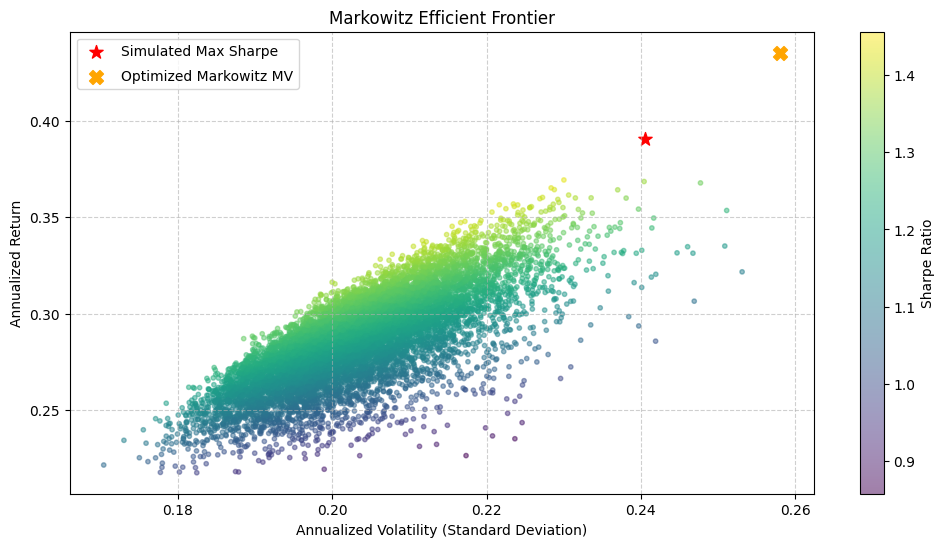


--- Markowitz MV Out-of-Sample Report ---
Total Return: 660.14%
Annualized Return: 48.30%
Annualized Volatility: 35.30%
Sharpe Ratio: 1.25
Max Drawdown: -50.78%

--- Plotting Phase 1: Markowitz MV Evaluation (Out-of-Sample) ---


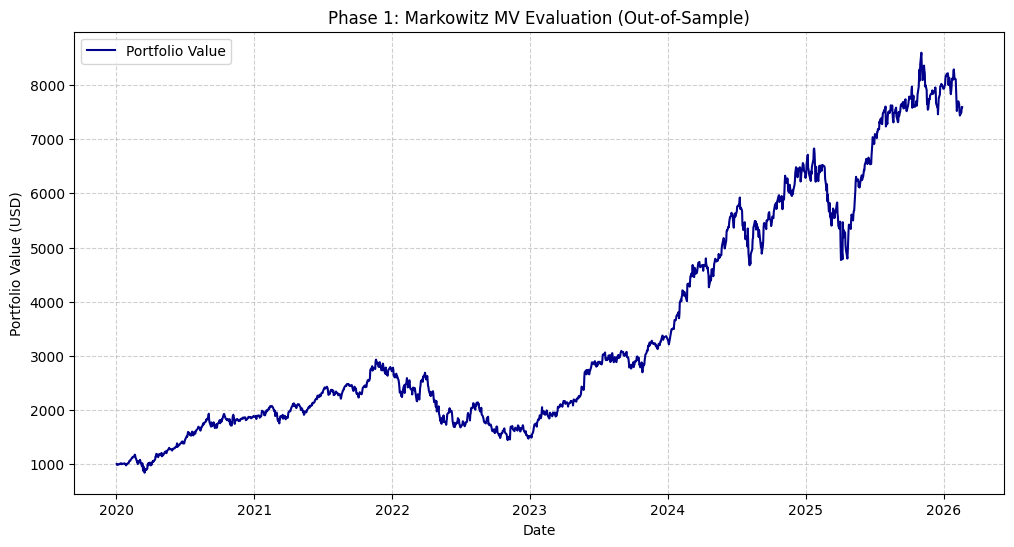


--- Plotting Phase 1: Strategy Comparison (Out-of-Sample) ---


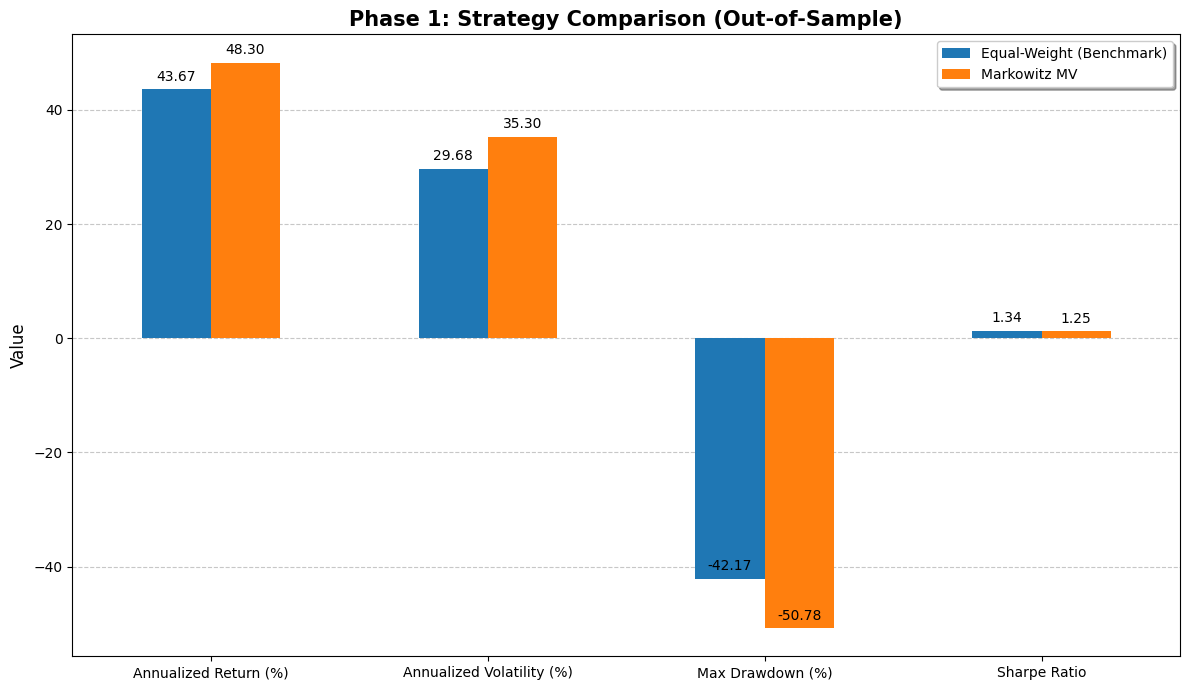

In [40]:
portfolio.runPhase1()


--- Phase 2: Robust covariance + CVaR/risk-parity/max-diversification Optimization ---


[*********************100%***********************]  1 of 1 completed


Optimal Phase 2 Weights (Last Rebalance: 2025-12-31):
  AAPL: 0.57%
  AMZN: 0.00%
  AVGO: 0.00%
  BRK-B: 30.00%
  GOOGL: 27.51%
  META: 9.24%
  MSFT: 30.00%
  NVDA: 0.00%
  TSLA: 0.00%
  TSM: 2.68%
Verification: Total Weights Sum = 1.0000

--- Phase 2: minCvar (ewma) Out-of-Sample Report ---
Total Return:          238.29%
CAGR:                  22.06%
Annualized Volatility: 24.97%
Sharpe Ratio:          0.76
Sortino Ratio:         0.73
Calmar Ratio:          0.80
Max Drawdown:          -32.55%
CVaR 95%:              3.71%
Stressed regime:       0.0% of rebalance dates

--- Plotting Phase 2: Phase 2: minCvar (ewma) (Out-of-Sample) ---


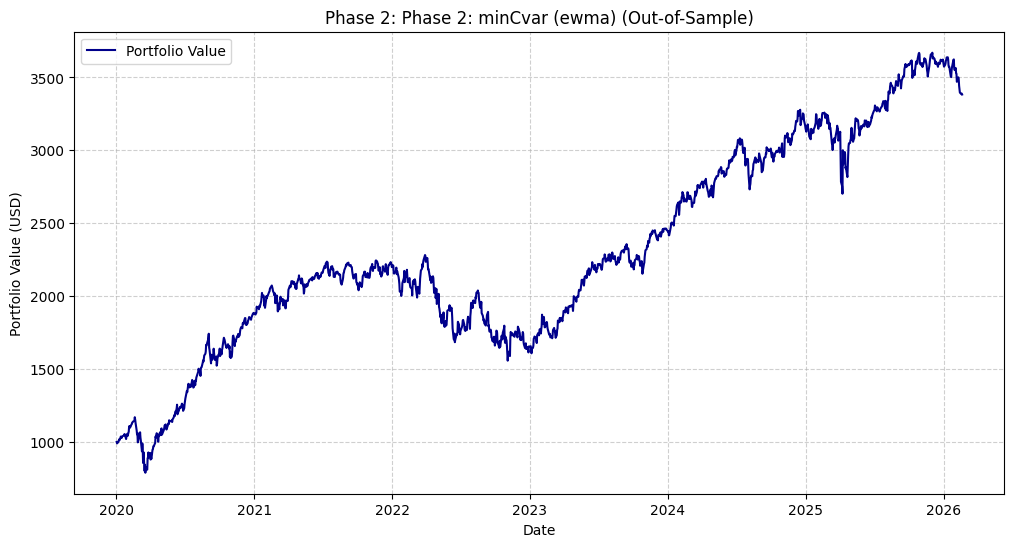


--- Plotting Phase 2: Strategy Comparison (Out-of-Sample) ---


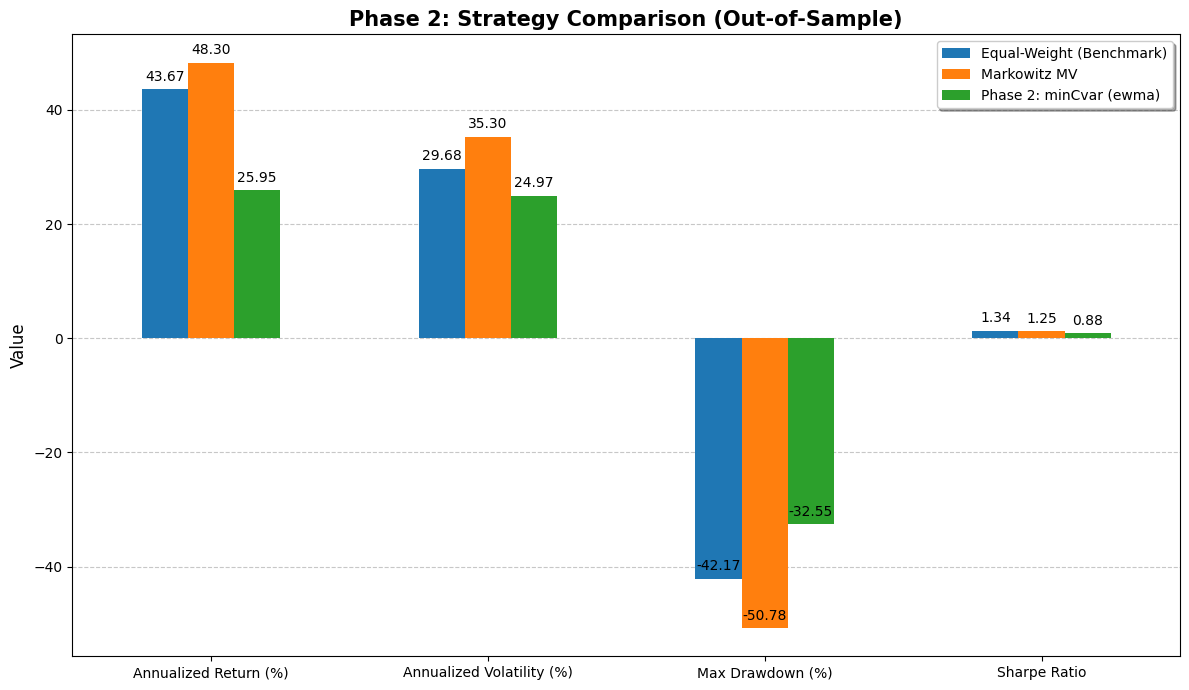

In [41]:
portfolio.runPhase2()